# Dataset Overview

The dataset contains detailed Brazilian export records obtained from the Brazilian Ministry of Development, Industry, Trade and Services (MDIC). The data is provided as annual CSV files using semicolon (;) as the delimiter.

Each record represents an export transaction and includes information such as:

* Year and month of the transaction
* NCM (Mercosur Common Nomenclature) product code
* Statistical unit code
* Destination country code
* Brazilian state (UF) code
* Mode of transport
* Customs office code
* Statistical quantity
* Net weight (kg)
* FOB value (US$)

FOB (Free On Board) represents the value of exported goods at the point of shipment. It includes the cost of the goods and domestic transportation up to the port of export but excludes international freight and insurance costs.

Source: https://www.gov.br/mdic/pt-br/assuntos/comercio-exterior/estatisticas/base-de-dados-bruta

The original column names are provided in Portuguese, following the official MDIC documentation. During the data transformation phase, implemented with dbt, the columns will be renamed to descriptive English names to improve readability and maintain consistency throughout the project.

## Project workflow

* Raw CSV files (MDIC)
* Initial data profiling (this notebook)
* Data transformation and modeling with dbt
* Business analysis
* Dashboard development in Tableau/Power BI

## Importing Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Exports

## Data Quality

In [2]:

dataframes = []
for year in range(2021,2025):

    file_path= f"../data/raw/Exports/EXP_{year}.csv"
    pd.set_option("display.float_format", "{:,.2f}".format) # Displays float type without the scientific notation
    exports = pd.read_csv(file_path,
                          sep=";",
                          encoding="latin1")
    
    dataframes.append(exports)

exports_df = pd.concat(dataframes, ignore_index = True)


In [3]:
exports_df.head()

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB
0,2021,1,40169990,10,361,SP,1,817800,5353,5353,42235
1,2021,2,94035000,11,317,RS,1,1017700,487,49670,53961
2,2021,11,35051000,10,63,MG,7,1017500,144000,144000,99654
3,2021,4,61023000,11,249,SP,4,817600,14,5,1087
4,2021,2,82111000,11,63,RS,7,1017503,7708,1105,12488


In [4]:
exports_df.dtypes

CO_ANO         int64
CO_MES         int64
CO_NCM         int64
CO_UNID        int64
CO_PAIS        int64
SG_UF_NCM     object
CO_VIA         int64
CO_URF         int64
QT_ESTAT       int64
KG_LIQUIDO     int64
VL_FOB         int64
dtype: object

In [5]:
exports_df.describe()

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB
count,"5,718,798.00","5,718,798.00","5,718,798.00","5,718,798.00","5,718,798.00","5,718,798.00","5,718,798.00","5,718,798.00","5,718,798.00","5,718,798.00"
mean,"2,022.43",6.31,"51,227,946.68",10.68,386.83,3.08,"797,899.02","358,974.55","500,172.21","211,600.90"
std,1.08,3.31,"31,428,355.66",1.72,238.66,2.68,"338,467.58","36,338,648.29","38,307,669.94","5,441,015.57"
min,"2,021.00",1.00,"1,012,100.00",10.00,13.00,0.00,"117,600.00",0.00,0.00,0.00
25%,"2,021.00",4.00,"21,012,010.00",10.00,169.00,1.00,"817,600.00",5.00,5.00,88.00
50%,"2,022.00",6.00,"52,093,200.00",10.00,361.00,1.00,"817,800.00",34.00,40.00,787.00
75%,"2,023.00",9.00,"84,314,390.00",11.00,586.00,4.00,"917,800.00",576.00,961.00,"11,904.00"
max,"2,024.00",12.00,"97,069,000.00",22.00,890.00,15.00,"9,999,999.00","14,646,306,000.00","24,030,871,000.00","2,102,966,398.00"


In [6]:
exports_df.isnull().sum()

CO_ANO        0
CO_MES        0
CO_NCM        0
CO_UNID       0
CO_PAIS       0
SG_UF_NCM     0
CO_VIA        0
CO_URF        0
QT_ESTAT      0
KG_LIQUIDO    0
VL_FOB        0
dtype: int64

In [7]:
print(exports_df.duplicated().sum())

0


In [8]:
exports_df.shape

(5718798, 11)

In [9]:
exports_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5718798 entries, 0 to 5718797
Data columns (total 11 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   CO_ANO      int64 
 1   CO_MES      int64 
 2   CO_NCM      int64 
 3   CO_UNID     int64 
 4   CO_PAIS     int64 
 5   SG_UF_NCM   object
 6   CO_VIA      int64 
 7   CO_URF      int64 
 8   QT_ESTAT    int64 
 9   KG_LIQUIDO  int64 
 10  VL_FOB      int64 
dtypes: int64(10), object(1)
memory usage: 479.9+ MB


### Check the number of unique values in each column

In [10]:
exports_df.nunique()

CO_ANO             4
CO_MES            12
CO_NCM          9120
CO_UNID           13
CO_PAIS          249
SG_UF_NCM         28
CO_VIA            13
CO_URF            78
QT_ESTAT      226849
KG_LIQUIDO    283904
VL_FOB        469279
dtype: int64

### Check the number of unique countries 

In [11]:
countries = pd.read_csv("../data/PAIS.csv", sep=";", encoding="latin1")

countries.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/PAIS.csv'

In [ ]:
countries["CO_PAIS"].nunique()


281

In [ ]:
countries.shape

(281, 6)

In [ ]:
unused_countries = countries[
    ~countries["CO_PAIS"].isin(exports_df["CO_PAIS"])
]

unused_countries[["CO_PAIS", "NO_PAIS"]]

,CO_PAIS,NO_PAIS
0,0,Não Definido
4,20,"Alboran-Perejil, Ilhas"
6,25,Alemanha Oriental
13,47,Antilhas Holandesas
34,100,Internação na Zona Franca de Manaus
47,150,"Canal, Ilhas do (Guernsey)"
48,151,"Canárias, Ilhas"
49,152,"Canal, Ilhas do (Jersey)"
72,237,Dubai
112,358,Iêmen Democrático


The “Countries” dimension contains 281 codes, including countries, territories, dependencies, and administrative codes used by Comex Stat. Between 2021 and 2023, 249 distinct destinations were identified for Brazilian exports. The unused codes correspond mainly to former countries (such as the USSR and Yugoslavia), territories with little commercial activity, and special administrative codes (such as “Undeclared” and “International Organizations”), indicating consistency between the “countries” dimension and the export database.

### Check if all months are represented

In [ ]:
exports_df["CO_MES"].value_counts().sort_index()

CO_MES
1     458436
2     450734
3     517117
4     507373
5     534475
6     517552
7     523816
8     531638
9     522233
10    385581
11    373005
12    396838
Name: count, dtype: int64

In [ ]:
exports_df[exports_df["CO_ANO"] == 2024]["CO_MES"].value_counts().sort_index()

CO_MES
1    119172
2    116582
3    130150
4    136705
5    134950
6    127535
7    140715
8    132040
9    141127
Name: count, dtype: int64

The monthly distribution of transactions is relatively consistent throughout the available months. A noticeable decrease is observed from October to December; however, this is explained by the 2024 dataset containing records only from January to September. Therefore, the lower number of transactions in the last quarter should not be interpreted as a seasonal decline in Brazilian exports.

## Distribution of Numerical Variables

### FOB Value (US$)

#### Distribution of FOB Value

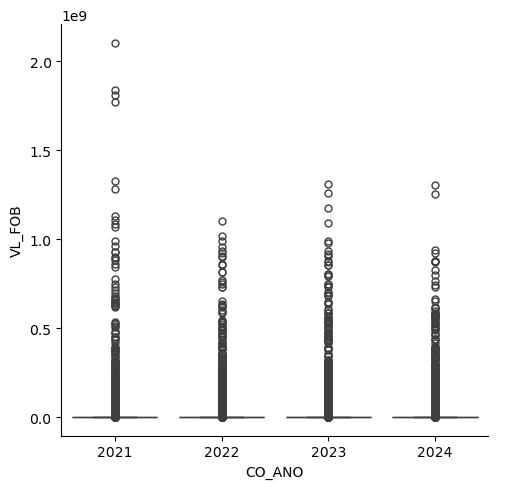

In [ ]:
sns.catplot(x="CO_ANO", y="VL_FOB", data= exports_df, kind= "box")

The boxplot reveals a highly skewed distribution of FOB values, with numerous extreme outliers. Since the large range of values compresses most observations near the bottom of the plot, a logarithmic transformation is applied in the next step to improve visualization.

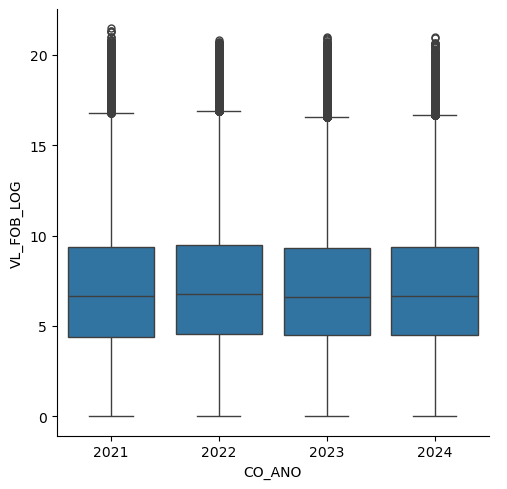

In [ ]:
exports_df["VL_FOB_LOG"] = np.log1p(exports_df["VL_FOB"])
sns.catplot(x="CO_ANO", y="VL_FOB_LOG", data= exports_df, kind= "box")

After applying the logarithmic transformation, the distributions of FOB values become much easier to compare across the three years. The median and interquartile range (IQR) are very similar for 2021, 2022, and 2023, indicating that the typical export transaction remained relatively stable over time. Although outliers are still present, they no longer dominate the visualization, allowing the overall distribution of the data to be observed more clearly.

#### Total amount of FOB value for each year

In [ ]:
exports_by_year = exports_df.groupby("CO_ANO")["VL_FOB"].sum()
print(exports_by_year.map(lambda x: f"{x:,.0f}"))


CO_ANO
2021    280,814,577,460
2022    334,136,038,220
2023    339,695,766,008
2024    255,456,405,064
Name: VL_FOB, dtype: object


Between 2021 and 2023, the total FOB value of Brazilian exports showed a clear upward trend. In 2021, exports totaled approximately US$ 281 billion. This increased to US$ 334 billion in 2022 and reached US$ 340 billion in 2023. The most significant growth occurred between 2021 and 2022, while the increase between 2022 and 2023 was comparatively modest. Although the total FOB value for 2024 is approximately US$ 255 billion, this value should not be directly compared with previous years because the dataset only includes transactions from January to September 2024.

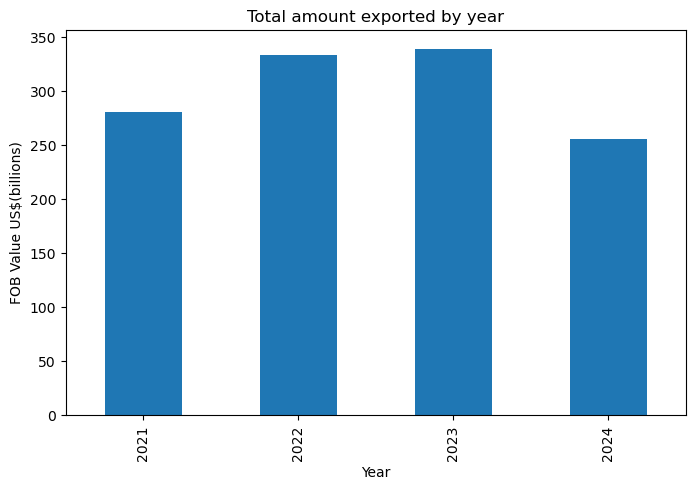

In [ ]:
exports_by_year = exports_df.groupby("CO_ANO")["VL_FOB"].sum()/1e9  # Convert values from US dollars to billions of US dollars for better visualization
ax= exports_by_year.plot(kind="bar", figsize= (8,5))
ax.ticklabel_format(style="plain", axis ="y")
plt.ylabel("FOB Value US$(billions)")
plt.xlabel("Year")
plt.title("Total amount exported by year")
plt.show()


**Note**: The 2024 data covers only the period from January to September. Therefore, comparisons between 2024 and previous full years should be interpreted with caution.

#### Median FOB Value for each year

The following bar chart shows the median FOB value for each year. The median is used instead of the mean because the distribution of FOB values is highly skewed and contains many extreme outliers. Therefore, the median provides a more representative measure of a typical export transaction.

CO_ANO
2021   764.00
2022   864.00
2023   739.00
2024   790.00
Name: VL_FOB, dtype: float64


<Axes: xlabel='CO_ANO'>

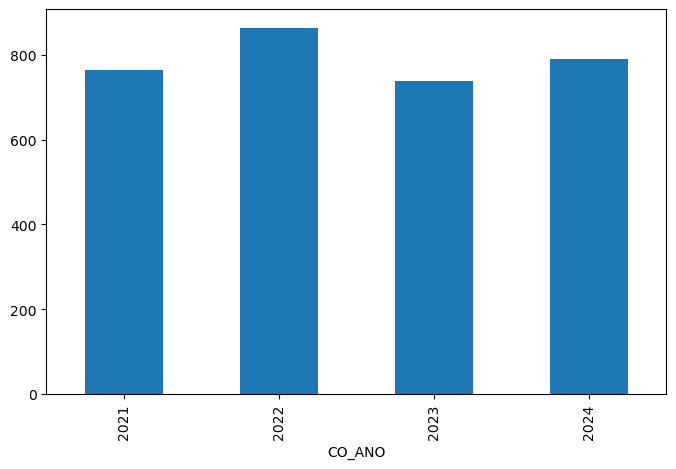

In [ ]:
print(exports_df.groupby("CO_ANO")["VL_FOB"].median())
exports_df.groupby("CO_ANO")["VL_FOB"].median().plot(kind="bar", figsize = (8,5))


### Statistical Quantity

It represents the statistical quantity of the merchandise, the unit of which depends on the product (for example, kilograms, liters, units, square meters, etc., according to the NCM code and the statistical unit).

#### Distribution of Statistical Quantity

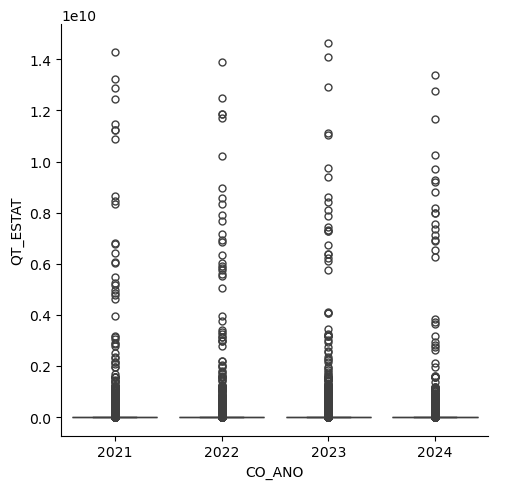

In [ ]:
sns.catplot(x="CO_ANO", y="QT_ESTAT", data= exports_df, kind= "box")


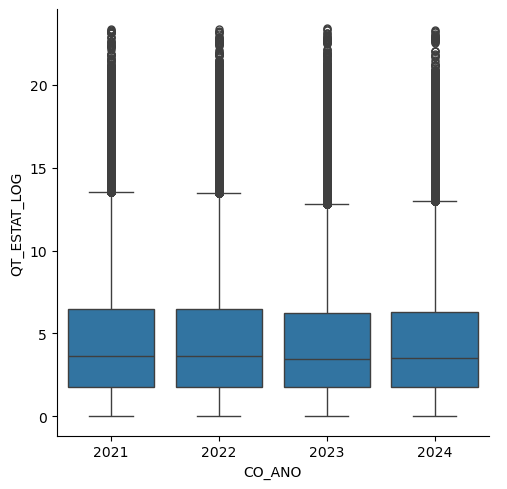

In [ ]:
exports_df["QT_ESTAT_LOG"] = np.log1p(exports_df["QT_ESTAT"])
sns.catplot(x="CO_ANO", y="QT_ESTAT_LOG", data= exports_df, kind= "box")

The distribution of the statistical quantity (QT_ESTAT) is highly skewed, with a large number of extreme outliers. As a result, the original boxplot compresses most observations near the bottom of the graph. After applying a logarithmic transformation, the distributions become much easier to compare across years. The medians and interquartile ranges remain very similar, indicating that the typical statistical quantity of export transactions was relatively stable throughout the analyzed period.

#### Total Amount of Statistical Quantity by Year

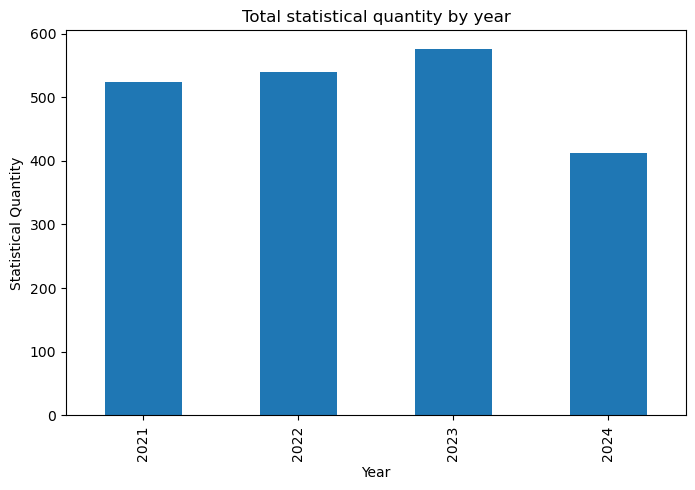

In [ ]:
stat_quant_by_year = exports_df.groupby("CO_ANO")["QT_ESTAT"].sum()/1e9
ax= stat_quant_by_year.plot(kind="bar", figsize= (8,5))
ax.ticklabel_format(style="plain", axis ="y")
plt.ylabel("Statistical Quantity")
plt.xlabel("Year")
plt.title("Total statistical quantity by year")
plt.show()

#### Median of Statitical Quantity by Year

CO_ANO
2021   37.00
2022   36.00
2023   31.00
2024   32.00
Name: QT_ESTAT, dtype: float64


<Axes: xlabel='CO_ANO'>

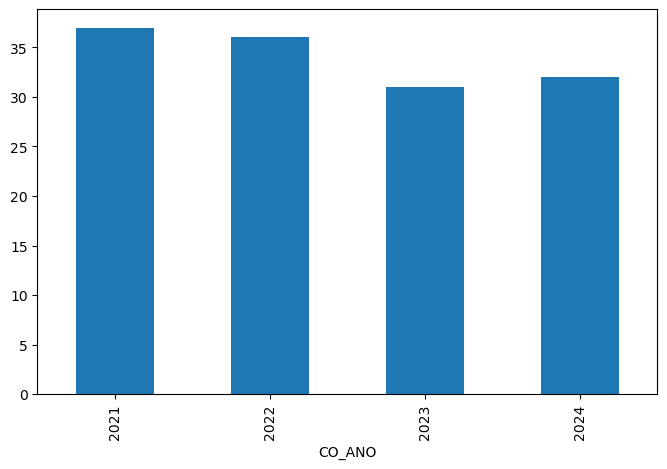

In [ ]:
print(exports_df.groupby("CO_ANO")["QT_ESTAT"].median())
exports_df.groupby("CO_ANO")["QT_ESTAT"].median().plot(kind="bar", figsize = (8,5))

### Net Weight (Kg)

#### Distribution of Net Weight 

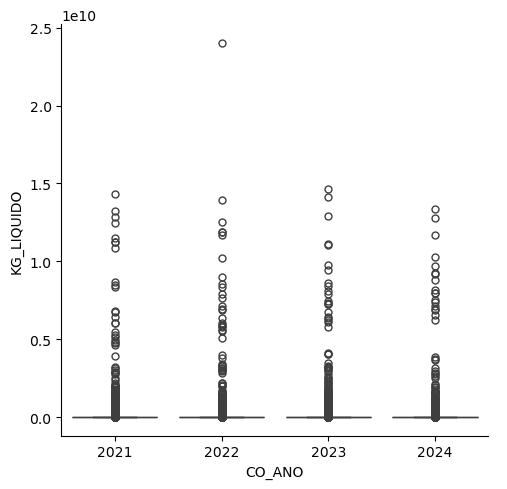

In [ ]:
sns.catplot(x="CO_ANO", y="KG_LIQUIDO", data= exports_df, kind= "box")

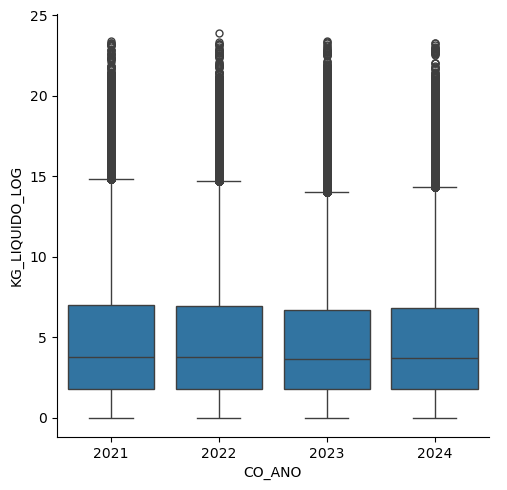

In [ ]:
exports_df["KG_LIQUIDO_LOG"] = np.log1p(exports_df["KG_LIQUIDO"])
sns.catplot(x="CO_ANO", y="KG_LIQUIDO_LOG", data= exports_df, kind= "box")

#### Total Amount Net Weight by Year

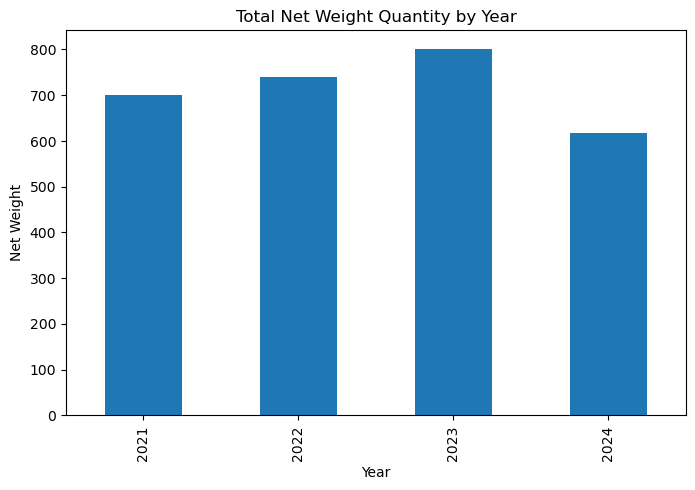

In [ ]:
net_weight_by_year = exports_df.groupby("CO_ANO")["KG_LIQUIDO"].sum()/1e9
ax= net_weight_by_year.plot(kind="bar", figsize= (8,5))
ax.ticklabel_format(style="plain", axis ="y")
plt.ylabel("Net Weight")
plt.xlabel("Year")
plt.title("Total Net Weight Quantity by Year")
plt.show()

#### Median of Net Weight by Year

CO_ANO
2021   42.00
2022   41.00
2023   38.00
2024   40.00
Name: KG_LIQUIDO, dtype: float64


<Axes: xlabel='CO_ANO'>

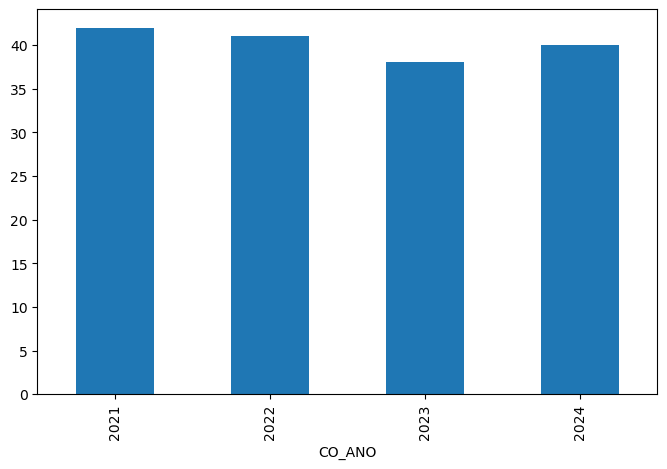

In [ ]:
print(exports_df.groupby("CO_ANO")["KG_LIQUIDO"].median())
exports_df.groupby("CO_ANO")["KG_LIQUIDO"].median().plot(kind="bar", figsize = (8,5))

# Imports

In [ ]:
dataframes = []
for year in range(2021,2025):

    file_path= f"../data/raw/Imports/IMP_{year}.csv"
    pd.set_option("display.float_format", "{:,.2f}".format) # Displays float type without the scientific notation
    imports = pd.read_csv(file_path,
                          sep=";",
                          encoding="latin1")
    
    dataframes.append(imports)

imports_df = pd.concat(dataframes, ignore_index = True)

In [ ]:
imports_df.head()

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,VL_FRETE,VL_SEGURO
0,2021,12,85065010,11,160,SP,1,817800,1830130,8096,125561,10186,212
1,2021,2,85013110,11,573,PR,1,917800,6,20,4478,36,0
2,2021,7,73071920,10,160,SP,1,817800,86604,86604,480783,21677,22
3,2021,11,73182900,10,386,RS,1,817800,859,859,13332,860,8
4,2021,8,82032010,10,386,RS,1,817800,7,7,504,3,1


In [ ]:
imports_df.dtypes

CO_ANO         int64
CO_MES         int64
CO_NCM         int64
CO_UNID        int64
CO_PAIS        int64
SG_UF_NCM     object
CO_VIA         int64
CO_URF         int64
QT_ESTAT       int64
KG_LIQUIDO     int64
VL_FOB         int64
VL_FRETE       int64
VL_SEGURO      int64
dtype: object

In [ ]:
imports_df.isnull().sum()

CO_ANO        0
CO_MES        0
CO_NCM        0
CO_UNID       0
CO_PAIS       0
SG_UF_NCM     0
CO_VIA        0
CO_URF        0
QT_ESTAT      0
KG_LIQUIDO    0
VL_FOB        0
VL_FRETE      0
VL_SEGURO     0
dtype: int64

In [ ]:
imports_df.describe()

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,VL_FRETE,VL_SEGURO
count,"7,794,970.00","7,794,970.00","7,794,970.00","7,794,970.00","7,794,970.00","7,794,970.00","7,794,970.00","7,794,970.00","7,794,970.00","7,794,970.00","7,794,970.00","7,794,970.00"
mean,"2,022.44",6.26,"69,182,891.46",10.47,312.42,2.60,"791,984.00","127,420.86","84,642.61","119,198.58","7,291.55",92.52
std,1.09,3.32,"22,756,662.22",0.79,219.63,1.72,"161,051.63","4,487,474.65","2,608,406.76","1,778,525.05","94,985.02","2,883.90"
min,"2,021.00",1.00,"1,012,100.00",10.00,13.00,1.00,"117,600.00",0.00,0.00,0.00,0.00,0.00
25%,"2,021.00",3.00,"47,032,100.00",10.00,160.00,1.00,"817,600.00",4.00,4.00,480.00,18.00,0.00
50%,"2,022.00",6.00,"84,133,090.00",10.00,249.00,1.00,"817,700.00",63.00,57.00,"3,593.00",211.00,1.00
75%,"2,023.00",9.00,"85,185,000.00",11.00,399.00,4.00,"817,800.00","1,800.00","1,191.00","26,426.00","1,545.00",12.00
max,"2,024.00",12.00,"97,069,000.00",22.00,997.00,11.00,"9,999,999.00","1,358,632,353.00","820,271,494.00","727,374,681.00","41,869,454.00","1,760,480.00"


In [ ]:
print(imports_df.duplicated().sum())

0


In [ ]:
imports_df.shape

(7794970, 13)

In [ ]:
imports_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7794970 entries, 0 to 7794969
Data columns (total 13 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   CO_ANO      int64 
 1   CO_MES      int64 
 2   CO_NCM      int64 
 3   CO_UNID     int64 
 4   CO_PAIS     int64 
 5   SG_UF_NCM   object
 6   CO_VIA      int64 
 7   CO_URF      int64 
 8   QT_ESTAT    int64 
 9   KG_LIQUIDO  int64 
 10  VL_FOB      int64 
 11  VL_FRETE    int64 
 12  VL_SEGURO   int64 
dtypes: int64(12), object(1)
memory usage: 773.1+ MB


In [ ]:
imports_df.nunique()

CO_ANO             4
CO_MES            12
CO_NCM          9623
CO_UNID           13
CO_PAIS          249
SG_UF_NCM         28
CO_VIA            10
CO_URF           102
QT_ESTAT      287117
KG_LIQUIDO    236933
VL_FOB        594073
VL_FRETE      152833
VL_SEGURO      15027
dtype: int64

In [ ]:
imports_df["CO_MES"].value_counts().sort_index()

CO_MES
1     663672
2     644703
3     700052
4     678300
5     696734
6     695337
7     711348
8     732778
9     719137
10    520909
11    521147
12    510853
Name: count, dtype: int64

## Distribution of Numerical Variables


### FOB Value (US$)


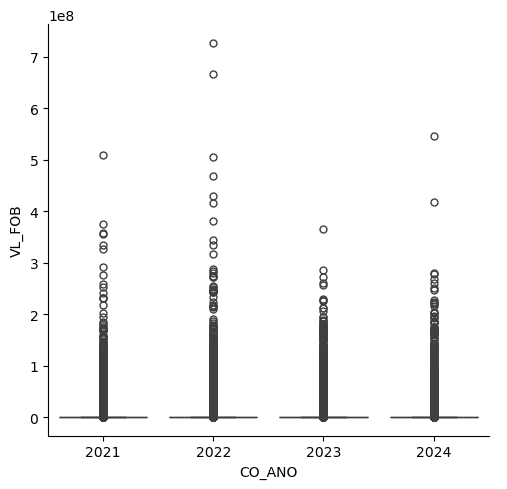

In [ ]:
sns.catplot(x="CO_ANO", y="VL_FOB", data= imports_df, kind= "box")

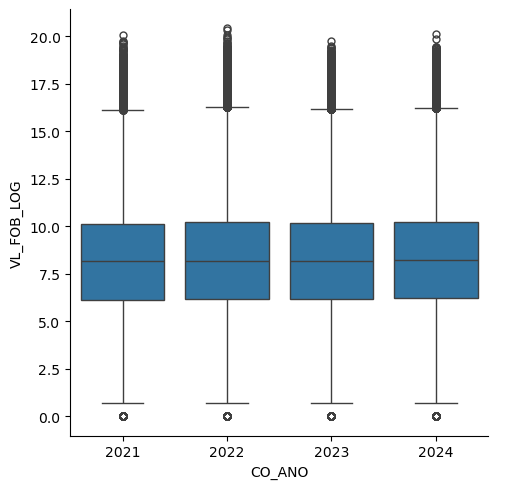

In [ ]:
imports_df["VL_FOB_LOG"] = np.log1p(imports_df["VL_FOB"])
sns.catplot(x="CO_ANO", y="VL_FOB_LOG", data= imports_df, kind= "box")

### Freight Value (US$)

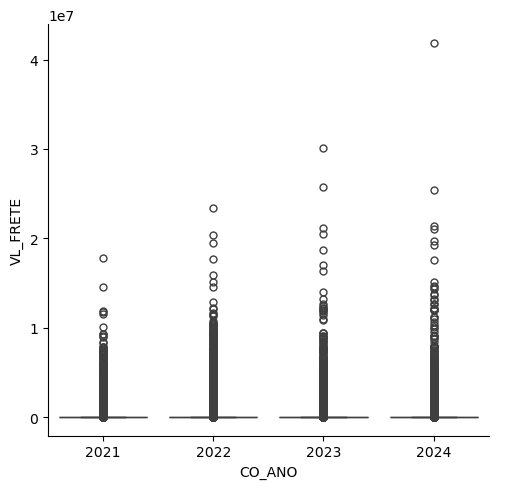

In [ ]:
sns.catplot(x="CO_ANO", y="VL_FRETE", data= imports_df, kind= "box")


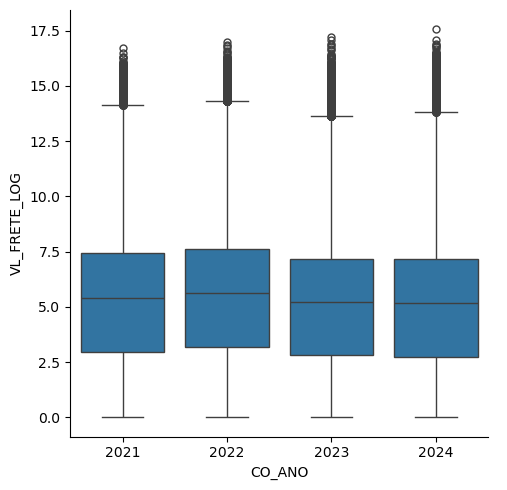

In [ ]:
imports_df["VL_FRETE_LOG"] = np.log1p(imports_df["VL_FRETE"])
sns.catplot(x="CO_ANO", y="VL_FRETE_LOG", data= imports_df, kind= "box")

### Insurance Value (US$)

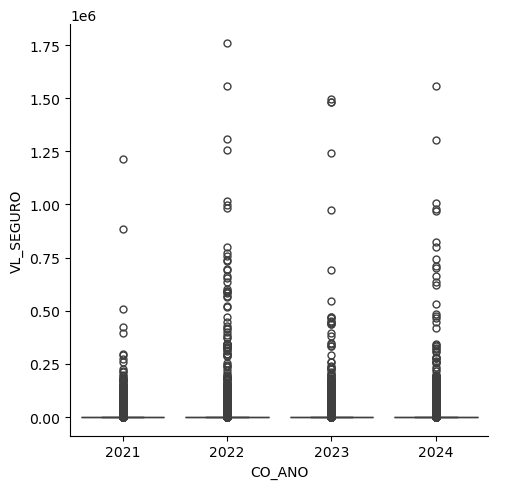

In [ ]:
sns.catplot(x="CO_ANO", y="VL_SEGURO", data= imports_df, kind= "box")


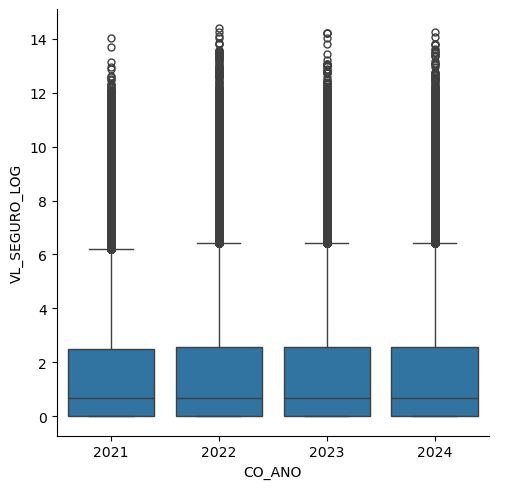

In [ ]:
imports_df["VL_SEGURO_LOG"] = np.log1p(imports_df["VL_SEGURO"])
sns.catplot(x="CO_ANO", y="VL_SEGURO_LOG", data= imports_df, kind= "box")

### Net Weight (Kg)

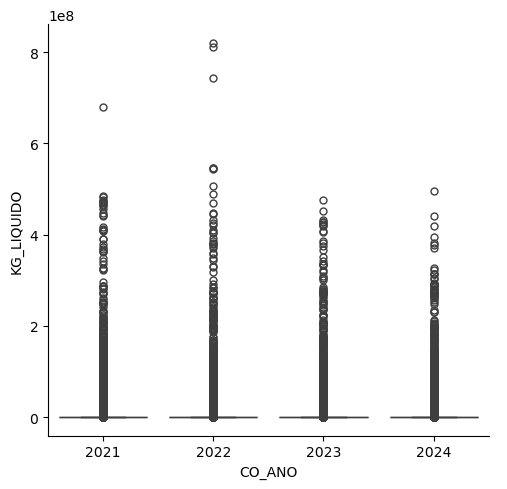

In [ ]:
sns.catplot(x="CO_ANO", y="KG_LIQUIDO", data= imports_df, kind= "box")


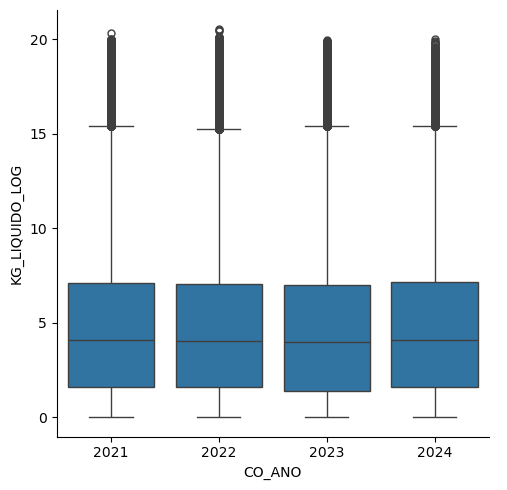

In [ ]:
imports_df["KG_LIQUIDO_LOG"] = np.log1p(imports_df["KG_LIQUIDO"])
sns.catplot(x="CO_ANO", y="KG_LIQUIDO_LOG", data= imports_df, kind= "box")

### Statistical Quantity

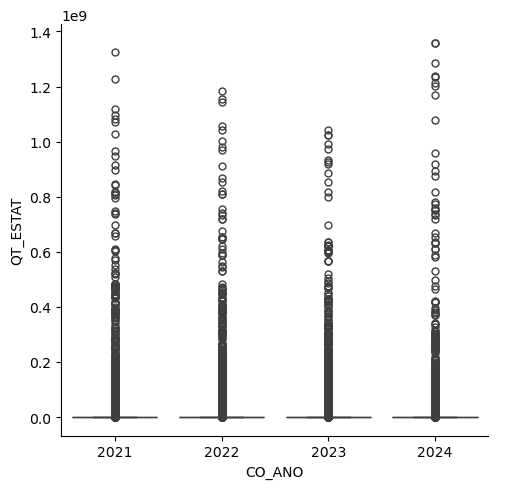

In [ ]:
sns.catplot(x="CO_ANO", y="QT_ESTAT", data= imports_df, kind= "box")


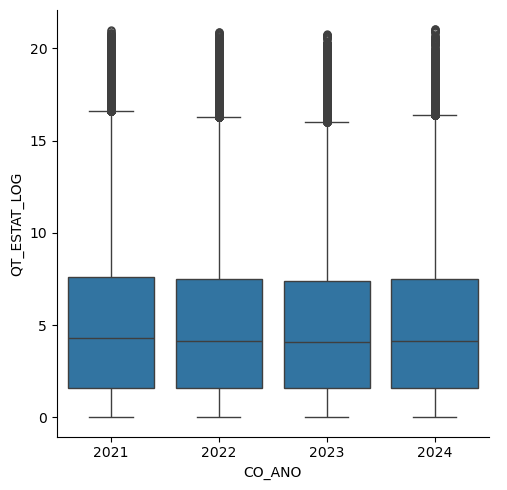

In [ ]:
imports_df["QT_ESTAT_LOG"] = np.log1p(imports_df["QT_ESTAT"])
sns.catplot(x="CO_ANO", y="QT_ESTAT_LOG", data= imports_df, kind= "box")

# EDA Dimension Tables

In [ ]:
ncm_cgce = pd.read_csv("../data/raw/NCM_CGCE.csv", sep = ";", encoding = "latin1")

In [ ]:
ncm_cgce.head()

,CO_CGCE_N3,NO_CGCE_N3,NO_CGCE_N3_ING,NO_CGCE_N3_ESP,CO_CGCE_N2,NO_CGCE_N2,NO_CGCE_N2_ING,NO_CGCE_N2_ESP,CO_CGCE_N1,NO_CGCE_N1,NO_CGCE_N1_ING,NO_CGCE_N1_ESP
0,110,Bens de capital (exceto equipamentos de transp...,"Capital goods, except industrial transport equ...","Bienes de capital, excepto equipo de transport...",11,"Bens de capital, exceto equipamentos de transp...","Capital goods, except industrial transport equ...","Bienes de capital, excepto equipo de transport...",1,BENS DE CAPITAL (BK),CAPITAL GOODS (BK),BIENES DE CAPITAL (BK)
1,120,Equipamentos de transporte industrial,Equipment for industrial transportation,Equipos de transporte industrial,12,Equipamentos de transporte industrial,Equipment for industrial transportation,Equipos de transporte industrial,1,BENS DE CAPITAL (BK),CAPITAL GOODS (BK),BIENES DE CAPITAL (BK)
2,210,"Alimentos e bebidas básicos, destinados princi...","Basic food and beverages, mainly for industry","Alimentos y bebidas básicos, principalmente pa...",21,"Alimentos e bebidas básicos, destinados princi...","Basic food and beverages, mainly for industry","Alimentos y bebidas básicos, principalmente pa...",2,BENS INTERMEDIÁRIOS (BI),INTERMEDIATE GOODS (BI),BIENES INTERMEDIOS (BI)
3,220,"Alimentos e bebidas elaborados, destinados pri...","Elaborated food and beverages, mainly for indu...","Alimentos y bebidas preparados, principalmente...",22,"Alimentos e bebidas elaborados, destinados pri...","Elaborated food and beverages, mainly for indu...","Alimentos y bebidas preparados, principalmente...",2,BENS INTERMEDIÁRIOS (BI),INTERMEDIATE GOODS (BI),BIENES INTERMEDIOS (BI)
4,230,Insumos industriais básicos,Basic industrial inputs,Insumos industriales básicos,23,Insumos industriais básicos,Basic industrial inputs,Insumos industriales básicos,2,BENS INTERMEDIÁRIOS (BI),INTERMEDIATE GOODS (BI),BIENES INTERMEDIOS (BI)


In [ ]:
ncm_cuci = pd.read_csv("../data/raw/NCM_CUCI.csv", sep = ";", encoding = "latin1")


In [ ]:
ncm_cuci.head()

,CO_CUCI_ITEM,NO_CUCI_ITEM,CO_CUCI_SUB,NO_CUCI_SUB,CO_CUCI_GRUPO,NO_CUCI_GRUPO,CO_CUCI_DIVISAO,NO_CUCI_DIVISAO,CO_CUCI_SEC,NO_CUCI_SEC
0,I,"Ouro, monetário",9710,"Ouro, não monetário (excluindo minérios de our...",971,"Ouro, não monetário (excluindo minérios de our...",97,"Ouro, não monetário (excluindo minérios de our...",9,MERCADORIAS E TRANSACOES NAO ESPECIFICADAS EM ...
1,II,Moeda de ouro e moeda corrente,9710,"Ouro, não monetário (excluindo minérios de our...",971,"Ouro, não monetário (excluindo minérios de our...",97,"Ouro, não monetário (excluindo minérios de our...",9,MERCADORIAS E TRANSACOES NAO ESPECIFICADAS EM ...
2,00111,Animais de raça para reprodução,11,Bovinos vivos,001,"Animais vivos, não incluído pescados ou crustá...",0,Animais vivos não incluídos no capítulo 03,0,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS
3,00119,"Outros, exceto animais de raça para reprodução",11,Bovinos vivos,001,"Animais vivos, não incluído pescados ou crustá...",0,Animais vivos não incluídos no capítulo 03,0,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS
4,00121,Ovinos vivos,12,Ovinos e caprinos vivos,001,"Animais vivos, não incluído pescados ou crustá...",0,Animais vivos não incluídos no capítulo 03,0,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS


In [ ]:
ncm = pd.read_csv("../data/raw/NCM.csv", sep = ";", encoding = "latin1")


In [ ]:
ncm.head()

,CO_NCM,CO_UNID,CO_SH6,CO_PPE,CO_PPI,CO_FAT_AGREG,CO_CUCI_ITEM,CO_CGCE_N3,CO_SIIT,CO_ISIC_CLASSE,CO_EXP_SUBSET,NO_NCM_POR,NO_NCM_ESP,NO_NCM_ING
0,49011000,10,490110,"3,521.00","3,521.00",3.00,89215,322,"9,000.00",5811,"8,099.00","Livros, brochuras e impressos semelhantes, em ...","Libros, folletos, impresos similares, en hojas...","Books, brochures, similar printed papers, in s..."
1,49019100,10,490191,"3,521.00","3,521.00",3.00,89216,322,"9,000.00",5811,"8,099.00","Dicionários e enciclopédias, mesmo em fascículos","Diccionarios y enciclopedias, incluso en fascí...","Dictionaries and encyclopaedias, serial instal..."
2,49019900,10,490199,"3,521.00","3,521.00",3.00,89219,322,"9,000.00",5811,"8,099.00","Outros livros, brochuras e impressos semelhantes","Otros libros, folletos y impresos similares","Oth.printed books, brochures and similar printed"
3,49021000,10,490210,"3,521.00","3,521.00",3.00,89221,322,"9,000.00",5813,"8,099.00","Jornais e publicações periódicas, impressos, m...","Diarios y publicaciones, impresos, periodo>=4 ...","Newspapers, journals, printed, periodical>=4 t..."
4,52102910,10,521029,"3,840.00","3,840.00",3.00,65251,240,"4,000.00",1312,"1,605.00",Tecidos de algodão que contenham menos de 85 %...,"Tejidos de algodón, blanqueados, con fibras si...","Fabrics of cotton, bleached, synthetic or arti..."


In [ ]:
pais = pd.read_csv("../data/raw/PAIS.csv", sep = ";", encoding = "latin1")


In [ ]:
pais.head()

,CO_PAIS,CO_PAIS_ISON3,CO_PAIS_ISOA3,NO_PAIS,NO_PAIS_ING,NO_PAIS_ESP
0,0,898,ZZZ,Não Definido,Not defined,No definido
1,13,4,AFG,Afeganistão,Afghanistan,Afganistan
2,15,248,ALA,"Aland, Ilhas",Aland Islands,"Alans, Islas"
3,17,8,ALB,Albânia,Albania,Albania
4,20,724,ESP,"Alboran-Perejil, Ilhas","Alboran-Perejil, Islands","Alboran-Perejil, Islas"
